<a href="https://colab.research.google.com/github/JesusRamos01/ANALISIS/blob/main/lectura_archivos_desde_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Logo

# Lectura de diferentes tipos de archivos desde GitHub

En este notebook se muestran ejemplos de cómo **leer distintos tipos de archivos** almacenados en un repositorio de GitHub utilizando **Python y pandas**.

Los tipos de archivos que veremos son:
- CSV
- TXT delimitado
- JSON
- Archivos de Excel (`.xlsx`) - con diferentes hojas.
- Archivos Parquet (`.parquet`)
- Bases de datos (mysql)

Para que los ejemplos funcionen con tus propios datos, solo necesitas reemplazar las URL de ejemplo por los **enlaces `raw`** (crudos) de tus archivos en GitHub.

## 1. Preparación del entorno

Importamos las librerías necesarias. Principalmente usaremos `pandas`. Para Parquet es recomendable tener instalados `pyarrow` o `fastparquet`.

In [5]:
import pandas as pd
import numpy as np

# Opcional: mostrar más filas/columnas al imprimir dataframes
pd.set_option("display.max_rows", 5)
pd.set_option("display.max_columns", 10)

## 2. ¿Cómo obtener la URL `raw` de un archivo en GitHub?

1. Abre el archivo en GitHub.
2. Haz clic en el botón **Raw** (o "Bruto" o "crudo")
3. Copia la URL que aparece en el navegador. Esa será la URL que usaremos en `pandas`.

En los ejemplos siguientes se usan URL públicas conocidas o se dejan como **plantilla** para que las reemplaces por tus propios enlaces.

## 3. Lectura de archivos CSV desde GitHub

Los archivos CSV son uno de los formatos más comunes para almacenar datos tabulares.

Usaremos una URL de ejemplo del repositorio público `seaborn-data`. Puedes reemplazarla por la tuya.

In [6]:
import pandas as pd
# URL de ejemplo de un CSV público en GitHub (dataset 'tips' de seaborn)

csv_url="https://raw.githubusercontent.com/JesusRamos01/ANALISIS/refs/heads/main/Clientes_2021.csv"

# Leemos el archivo CSV directamente desde la URL

df_csv = pd.read_csv(csv_url, sep =",")

# Mostramos las primeras filas para verificar
df_csv.head(15)

,Documento,Nombre,Apellido,Genero,Fecha de Nacimiento
0,91328983.0,Vanesa,Olmos,femenino,19-May-03
1,20638872.0,Amadeo,Villareal,masculino,23-Oct-94
...,...,...,...,...,...
13,93928091.0,Alejo,Lugo,masculino,5-Jun-19
14,20477078.0,Elías,Macías,masculino,11-Ago-32


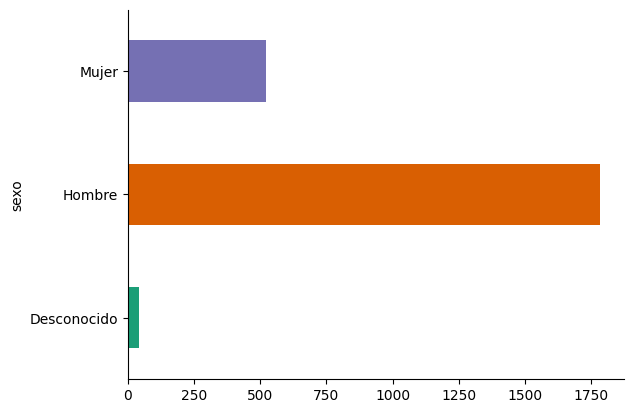

In [7]:
from matplotlib import pyplot as plt
import seaborn as sns
txt_url = "https://raw.githubusercontent.com/hmedrano1979/ITC/refs/heads/main/fichero_lab_unir.txt"

# Leemos el archivo CSV directamente desde la URL

df_txt = pd.read_csv(txt_url, sep=",",)
df_txt.groupby('sexo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

## 4. Lectura de archivos TXT delimitados desde GitHub

---



Cuando el archivo usa otro delimitador distinto a la coma (por ejemplo tabulación `\t` o punto y coma `;`), se puede indicar el separador con el parámetro `sep`.

In [8]:
# EJEMPLO 2: archivo separado por punto y coma
# Reemplaza esta URL por la de tu archivo TXT en GitHub

txt_url = "https://raw.githubusercontent.com/JesusRamos01/ANALISIS/refs/heads/main/fichero_lab_unir.txt"

# Leemos el archivo CSV directamente desde la URL

df_txt = pd.read_csv(txt_url, sep=",",)
df_txt.head(2)

,Unnamed: 0,num_expediente,fecha,hora,localizacion,...,coordenada_y_utm,positiva_alcohol,positiva_droga,tipo_vehiculo,lesividad
0,0,2021S000047,01/01/2021,11:38:00,CALL. JOSE BERGAMIN / CALL. FLORENCIO CANO CRI...,...,4.473.586.644,N,NaN,NaN,NaN
1,1,2021S000142,04/01/2021,11:30:00,PLAZA. GRECIA / AVDA. ARCENTALES wanda farola 20,...,4.476.216.426,N,NaN,NaN,NaN


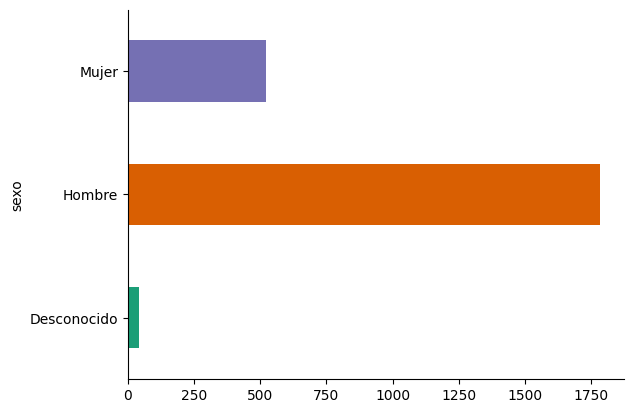

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns
df_txt.groupby('sexo').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [23]:
df_txt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2349 entries, 0 to 2348
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            2349 non-null   int64         
 1   num_expediente        2349 non-null   object        
 2   fecha                 2349 non-null   datetime64[ns]
 3   hora                  2349 non-null   object        
 4   localizacion          2349 non-null   object        
 5   numero                2349 non-null   object        
 6   cod_distrito          2349 non-null   int64         
 7   distrito              2349 non-null   object        
 8   tipo_accidente        2349 non-null   object        
 9   estado_meteorológico  2265 non-null   object        
 10  tipo_vehículo         845 non-null    object        
 11  tipo_persona          2349 non-null   object        
 12  rango_edad            2349 non-null   object        
 13  sexo              

In [10]:
df_txt["tipo_vehiculo"].unique()

array([nan, 'Bicicleta EPAC (pedaleo asistido)', 'Bicicleta'],
      dtype=object)

In [22]:
df_txt["fecha"]=df_txt["fecha"].astype("datetime64[ns]")

## 5. Lectura de archivos JSON desde GitHub

Los archivos JSON se utilizan para representar datos estructurados. `pandas` permite leerlos fácilmente con `read_json`.

A continuación se muestra un ejemplo con un JSON público. Si tu JSON tiene otro formato (por ejemplo, una lista de objetos) puede que necesites ajustar el parámetro `orient`.

In [11]:
# URL de ejemplo de un JSON público (películas de vega-datasets)
json_url = "https://raw.githubusercontent.com/vega/vega-datasets/master/data/movies.json"

# Leemos el archivo JSON
df_json = pd.read_json(json_url)

df_json.head()

,Title,US Gross,Worldwide Gross,US DVD Sales,Production Budget,...,Creative Type,Director,Rotten Tomatoes Rating,IMDB Rating,IMDB Votes
0,The Land Girls,146083.0,146083.0,NaN,8000000.0,...,None,None,NaN,6.1,1071.0
1,"First Love, Last Rites",10876.0,10876.0,NaN,300000.0,...,None,None,NaN,6.9,207.0
2,I Married a Strange Person,203134.0,203134.0,NaN,250000.0,...,None,None,NaN,6.8,865.0
3,Let's Talk About Sex,373615.0,373615.0,NaN,300000.0,...,None,None,13.0,NaN,NaN
4,Slam,1009819.0,1087521.0,NaN,1000000.0,...,Contemporary Fiction,None,62.0,3.4,165.0


### 5.1. JSON línea a línea (NDJSON)

Algunos archivos JSON tienen **una estructura por línea** (también llamado NDJSON o JSON Lines). En ese caso se usa `lines=True`.

In [12]:
# Plantilla para leer un JSON línea a línea (NDJSON)
json_url = "https://raw.githubusercontent.com/hmedrano1979/ITC/main/example_004_movies.json"

df = pd.read_json(json_url)
df.head(6)

,title,year,cast,genres,href,extract,thumbnail,thumbnail_width,thumbnail_height
0,After Dark in Central Park,1900,[],[],None,NaN,NaN,NaN,NaN
1,Boarding School Girls' Pajama Parade,1900,[],[],None,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
4,Clowns Spinning Hats,1900,[],[Silent],Clowns_Spinning_Hats,Clowns Spinning Hats is a black-and-white sile...,NaN,NaN,NaN
5,Capture of Boer Battery by British,1900,[],"[Short, Documentary, Silent]",Capture_of_Boer_Battery_by_British,Capture of Boer Battery by British is a black-...,https://upload.wikimedia.org/wikipedia/commons...,320.0,240.0


## 6. Lectura de archivos de Excel (`.xlsx`) desde GitHub

Para leer archivos de Excel almacenados en GitHub, normalmente la URL debe incluir el parámetro `?raw=1` o usar el enlace `raw`.

En este ejemplo se deja una URL de plantilla para que la reemplaces por tu archivo real.

In [13]:
# Plantilla de URL para un archivo de Excel en GitHub
#excel_url = "https://github.com/usuario/repositorio/raw/rama/ruta/archivo.xlsx"  # ERROR
import pandas as pd
excel_url = "https://raw.githubusercontent.com/hmedrano1979/ITC/main/Ventas%20(Trabajo%20final).xlsx"

# Lectura de una sola hoja (por defecto la primera)
#df_excel = pd.read_excel(excel_url)
#df_excel.head()

# Lectura de una hoja específica por nombre  Hoja 1
df_excel_hoja1 = pd.read_excel(excel_url, sheet_name="Cliente")
df_excel_hoja1.head()


,Identificación_Clie,Nombres,Apellidos,Genero,Celular,Nacionalidad,Estado Civil
0,CLIE1000,Sofía,Díaz,Femnino,3690840711,Colombiano,Soltero
1,CLIE1001,Andrés,López,Masculino,3458297268,Chileno,Casado
2,CLIE1002,Laura,Pérez,Femnino,3796345771,Argentino,Unión Libre
3,CLIE1003,Fernando,Martínez,Masculino,3175272825,Argentino,Unión Libre
4,CLIE1004,María,Torres,Femnino,3355109790,Chileno,Soltero


In [14]:
# Lectura de una hoja específica por nombre  Hoja 2
df_excel_hoja2 = pd.read_excel(excel_url, sheet_name="Articulo")
df_excel_hoja2.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CódigoArt,NaN,NaN,Nombre,Proveedor,Precio Compra,Categoría
3,ART100,NaN,NaN,Producto_0,Adidas,420496,Electrodoméstico
4,ART101,NaN,NaN,Producto_1,Hasbro,49255,Muebles


In [15]:

# Lectura de una hoja específica por nombre  Hoja 3
df_excel_hoja3 = pd.read_excel(excel_url, sheet_name="Vendedor")
df_excel_hoja3.head()

,Identificación_Vend,Nombres,Apellidos,Genero,Celular
0,VEND200,Bleider,Hernández,Masculino,3273198382
1,VEND201,Martin,Gómez,Masculino,3889697273
2,VEND202,Sandra,Gómez,Femenino,3644821826
3,VEND203,Yolaider,Martínez,Femenino,3779028607
4,VEND204,Pablo,Gómez,Masculino,3490105229


In [16]:
# Lectura de una hoja específica por nombre  Hoja 4
df_excel_hoja4 = pd.read_excel(excel_url, sheet_name="Factura")
df_excel_hoja4.head()

,Fecha,Todorico,#Factura,Cliente,Articulo,Vendedor,Cantidad,Precio Venta,SuperGiros
0,01/02/2023,NaN,FACT563,CLIE1012,ART125,VEND207,3,520000,NaN
1,02/02/2023,NaN,FACT551,CLIE1035,ART117,VEND201,5,350000,NaN
2,23/02/2023,NaN,FACT507,CLIE1005,ART115,VEND202,8,300000,NaN
3,11/03/2023,NaN,FACT543,CLIE1049,ART129,VEND209,1,450000,NaN
4,16/03/2023,NaN,FACT561,CLIE1033,ART125,VEND209,3,600000,NaN


## 7. Lectura de múltiples hojas de Excel como diccionario de DataFrames

Si el archivo de Excel tiene varias hojas que quieres cargar a la vez, puedes usar `sheet_name=None` para obtener un diccionario de DataFrames.

In [17]:
# Lectura de todas las hojas de un Excel (cuando tengas una URL válida)
all_sheets = pd.read_excel(excel_url, sheet_name=None)

# Recorremos las hojas y mostramos el nombre y las primeras filas
for sheet_name, df_sheet in all_sheets.items():
     print(f"Hoja: {sheet_name}")
     display(df_sheet.head())
     print("-" * 40)

Hoja: Cliente


,Identificación_Clie,Nombres,Apellidos,Genero,Celular,Nacionalidad,Estado Civil
0,CLIE1000,Sofía,Díaz,Femnino,3690840711,Colombiano,Soltero
1,CLIE1001,Andrés,López,Masculino,3458297268,Chileno,Casado
2,CLIE1002,Laura,Pérez,Femnino,3796345771,Argentino,Unión Libre
3,CLIE1003,Fernando,Martínez,Masculino,3175272825,Argentino,Unión Libre
4,CLIE1004,María,Torres,Femnino,3355109790,Chileno,Soltero


----------------------------------------
Hoja: Articulo


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CódigoArt,NaN,NaN,Nombre,Proveedor,Precio Compra,Categoría
3,ART100,NaN,NaN,Producto_0,Adidas,420496,Electrodoméstico
4,ART101,NaN,NaN,Producto_1,Hasbro,49255,Muebles


----------------------------------------
Hoja: Vendedor


,Identificación_Vend,Nombres,Apellidos,Genero,Celular
0,VEND200,Bleider,Hernández,Masculino,3273198382
1,VEND201,Martin,Gómez,Masculino,3889697273
2,VEND202,Sandra,Gómez,Femenino,3644821826
3,VEND203,Yolaider,Martínez,Femenino,3779028607
4,VEND204,Pablo,Gómez,Masculino,3490105229


----------------------------------------
Hoja: Factura


,Fecha,Todorico,#Factura,Cliente,Articulo,Vendedor,Cantidad,Precio Venta,SuperGiros
0,01/02/2023,NaN,FACT563,CLIE1012,ART125,VEND207,3,520000,NaN
1,02/02/2023,NaN,FACT551,CLIE1035,ART117,VEND201,5,350000,NaN
2,23/02/2023,NaN,FACT507,CLIE1005,ART115,VEND202,8,300000,NaN
3,11/03/2023,NaN,FACT543,CLIE1049,ART129,VEND209,1,450000,NaN
4,16/03/2023,NaN,FACT561,CLIE1033,ART125,VEND209,3,600000,NaN


----------------------------------------


## 8. Lectura de archivos Parquet desde GitHub

Los archivos Parquet son muy usados en entornos de Big Data por su compresión y eficiencia.

Para leer Parquet con `pandas`, se recomienda tener instaladas las librerías `pyarrow` o `fastparquet`. La lectura desde GitHub funciona igual que con otros formatos, usando la URL `raw`.

Ten en cuenta que, según el entorno donde ejecutes el notebook, puede que necesites instalar dependencias adicionales.

In [18]:
# Plantilla de URL para un archivo Parquet en GitHub
#parquet_url = "https://github.com/hmedrano1979/ITC/blob/main/fichero_lab_unir.parquet"  # ERROR
import pandas as pd

parquet_url = "https://github.com/hmedrano1979/ITC/blob/main/fichero_lab_unir.parquet?raw=1"
df_parquet = pd.read_parquet(parquet_url)
df_parquet.head()

,Unnamed: 0,num_expediente,fecha,hora,localizacion,...,coordenada_y_utm,positiva_alcohol,positiva_droga,tipo_vehiculo,lesividad
0,0,2021S000047,01/01/2021,11:38:00,CALL. JOSE BERGAMIN / CALL. FLORENCIO CANO CRI...,...,4.473.586.644,N,NaN,None,None
1,1,2021S000142,04/01/2021,11:30:00,PLAZA. GRECIA / AVDA. ARCENTALES wanda farola 20,...,4.476.216.426,N,NaN,None,None
2,2,2021S000142,04/01/2021,11:30:00,PLAZA. GRECIA / AVDA. ARCENTALES wanda farola 20,...,4.476.216.426,N,NaN,None,None
3,3,2021S000142,04/01/2021,11:30:00,PLAZA. GRECIA / AVDA. ARCENTALES wanda farola 20,...,4.476.216.426,N,NaN,None,None
4,4,2021S000142,04/01/2021,11:30:00,PLAZA. GRECIA / AVDA. ARCENTALES wanda farola 20,...,4.476.216.426,N,NaN,None,None


## 9. Resumen

En este notebook has visto cómo:

- Importar `pandas` y configurar opciones básicas de visualización.
- Obtener y usar la URL `raw` de archivos en GitHub.
- Leer archivos CSV, TXT, JSON, Excel y Parquet directamente desde GitHub.

Para adaptar este notebook a tu proyecto:
1. Sube tus archivos al repositorio de GitHub.
2. Obtén el enlace `raw` de cada archivo.
3. Reemplaza las URL de ejemplo por las tuyas.
4. Ajusta parámetros adicionales (delimitador, nombre de hoja, etc.) según el formato de tus datos.

De esta forma tendrás una **plantilla reutilizable** para leer datos desde GitHub en distintos formatos.